# Direct Strategy Data Engineering

## Requirements

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf


pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
sns.set_context('paper')

In [9]:
data = pd.read_csv('../data/raw/dataset_2022_2025.csv', index_col='datetime')
cols = [
    'price',
    'precipitation', 'cloud_cover', 'temperature', 'relative_humidity',
    'renewable_share_of_load', 'load',
    'sum_cbet'
]
data = data[cols]
print(data.shape)
data.head()

(26304, 8)


,price,precipitation,cloud_cover,temperature,relative_humidity,renewable_share_of_load,load,sum_cbet
datetime,,,,,,,,
2022-01-01 00:00:00+00:00,41.33,0.025,87.50,11.425,85.50,86.5,41177.8,-8.397
2022-01-01 01:00:00+00:00,43.22,0.025,100.00,11.225,86.25,86.3,39669.8,-6.700
2022-01-01 02:00:00+00:00,45.46,0.100,100.00,11.100,86.00,83.4,39448.7,-5.457
2022-01-01 03:00:00+00:00,37.67,0.000,96.75,10.850,86.50,80.0,39112.1,-4.827
2022-01-01 04:00:00+00:00,39.70,0.000,100.00,10.775,86.00,78.7,38358.2,-4.569


## Lagged Feature Selection

### Lagged Target Variables Selection

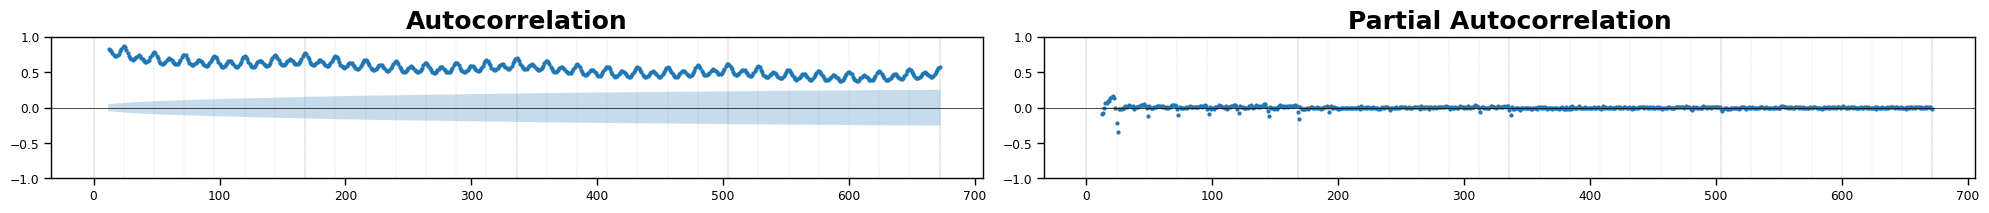

In [16]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(20, 20/9))

plot_acf(data['price'], ax=ax0, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
ax0.axhline(0, color='black', linewidth=0.5)
ax0.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
ax0.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
ax0.set_title('Autocorrelation', fontweight='bold', fontsize=18)

plot_pacf(data['price'], ax=ax1, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
ax1.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
ax1.set_title('Partial Autocorrelation', fontweight='bold', fontsize=18)

fig.tight_layout()
plt.show()

In [17]:
for l in [_ for _ in range(12, 26)] + [_ for _ in range(24, 24*3+1, 24)]:
    data.loc[:, f'price_l{l}'] = data.loc[:, 'price'].shift(l)

### Lagged Exogenous Variables Selection

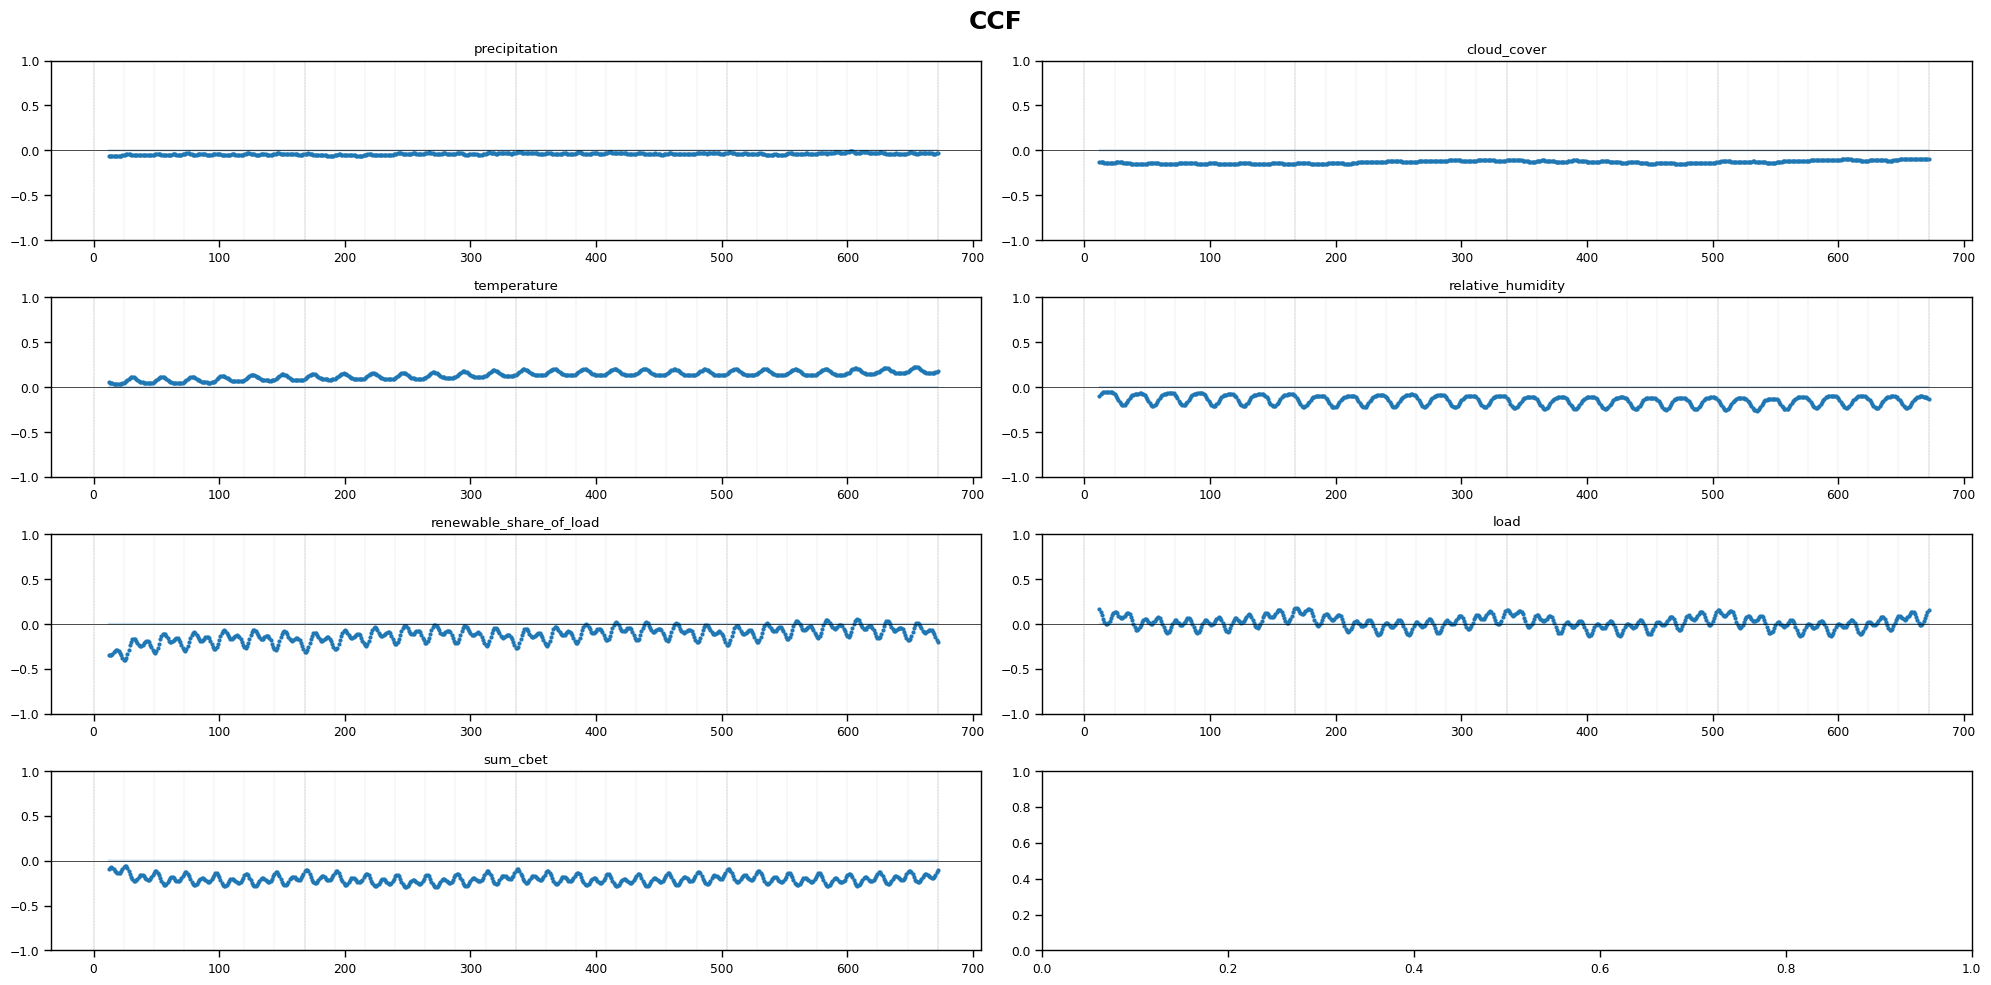

In [21]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 10))
axes = axes.flatten()

main_covar = [_ for _ in cols if 'price' not in _]
for j, col in enumerate(main_covar):
    ax = axes[j]
    plot_ccf(x=data['price'], y=data[col], alpha=0.05, ax=ax, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
    ax.set_title(col)

fig.suptitle('CCF', fontweight='bold', fontsize=18)
fig.tight_layout()
plt.show()